In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# set the random number generator seed for reproducibility
rng = np.random.default_rng(42)

In [2]:
x = np.linspace(-3, 3, 30)
y = np.sin(x) + np.random.normal(0, 0.2, size=len(x))

Text(0.5, 1.0, 'sample california housing data')

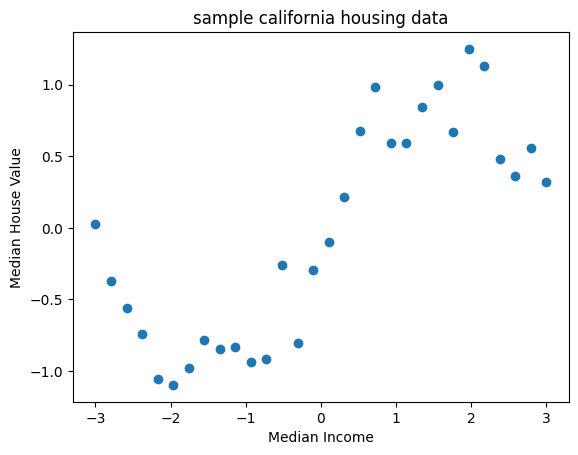

In [3]:
plt.scatter(x, y, marker='o')
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.title("sample california housing data")

### Split Data as Training and Validation Sets

In [4]:
# Train/val split
x_train, x_val, y_train, y_val = train_test_split(x, y, test_size=0.3)

### Normalizing Training Data

In [5]:
# Normalize Training inputs
x_mean = np.mean(x_train)
x_std = np.std(x_train)
xn = (x_train - x_mean) / x_std

# Normalize training outputs
y_mean = np.mean(y_train)
y_std = np.std(y_train)
yn = (y_train - y_mean) / y_std

### Linear Regression Model

In [6]:
class Model():
    
    def __init__(self, X, y, x_mean, x_std, y_mean, y_std, X_mean, X_std):
        self.X = X
        self.y = y
        self.m, self.n = self.X.shape
        self.w = rng.random(self.n)
        self.cost_history = []
        self.train_cost_history = []

        self.x_mean = x_mean
        self.x_std = x_std
        
        self.y_std = y_std
        self.y_mean = y_mean
        
        self.X_mean = X_mean
        self.X_std = X_std

    def fit(self, x_val=None, y_val=None, eta=0.1, eps=1e-6, max_iters=4000):

        # Prepare validation data
        if x_val is not None and y_val is not None:
            x_valn = (x_val - self.x_mean) / self.x_std
            X_val = create_polynomial_features(x_valn, self.n - 1)
            X_val[:, 1:] = (X_val[:, 1:] - self.X_mean) / self.X_std
            
            y_valn = (y_val - self.y_mean) / self.y_std
        
            self.X_val = X_val
            self.y_val = y_valn
            self.val_cost_history = []
                
        return self.gradient_descent(eta, eps, max_iters)

    def gradient_descent(self, eta=0.1, eps=1e-6, max_iters=10000):
        cost_change = 1
        num_iters = 0

        while cost_change > eps and num_iters < max_iters:
    
            # Forward pass (train)
            yhat = self.X @ self.w
        
            # Gradient
            gradient = -(self.X.T @ (self.y - yhat)) / self.m
        
            # Update weights
            self.w = self.w - eta * gradient
        
            # ---- TRAIN LOSS ----
            train_cost = (0.5 / self.m) * np.sum((self.y - (self.X @ self.w))**2)
            self.train_cost_history.append(train_cost)
        
            # ---- VALIDATION LOSS ----
            if hasattr(self, "X_val"):
                yhat_val = self.X_val @ self.w
                m_val = len(self.y_val)
                val_cost = (0.5 / m_val) * np.sum((self.y_val - yhat_val)**2)
                self.val_cost_history.append(val_cost)
        
            # Convergence check
            if len(self.train_cost_history) > 1:
                cost_change = abs(
                    self.train_cost_history[-1] - self.train_cost_history[-2]
                )
        
            num_iters += 1

        return  

    def compute_cost(self):
        return (0.5 / self.m) * np.sum((self.y - self.X @ self.w)**2)

    def predict(self, x_new): 
        x_new_norm = (x_new - self.x_mean) / self.x_std 
        X_new = create_polynomial_features(x_new_norm, self.n-1) 
        X_new[:, 1:] = (X_new[:, 1:] - self.X_mean) / self.X_std 
        yhat_norm = X_new @ self.w 
        yhat_real = yhat_norm * self.y_std + self.y_mean 
        return yhat_real
  
    def score(self):
        
        y_real = self.y * self.y_std + self.y_mean
        yhat_real = (self.X @ self.w) * self.y_std + self.y_mean
        
        ss_err = np.sum((y_real - yhat_real)**2)
        ss_tot = np.sum((y_real - np.mean(y_real))**2)
        
        r2 = 1 - (ss_err / ss_tot)
        
        return r2

### Creating Polynomial Features

In [7]:
# Function to create polynomical features
def create_polynomial_features(x, degree):
    return np.vstack([x**i for i in range(degree + 1)]).T

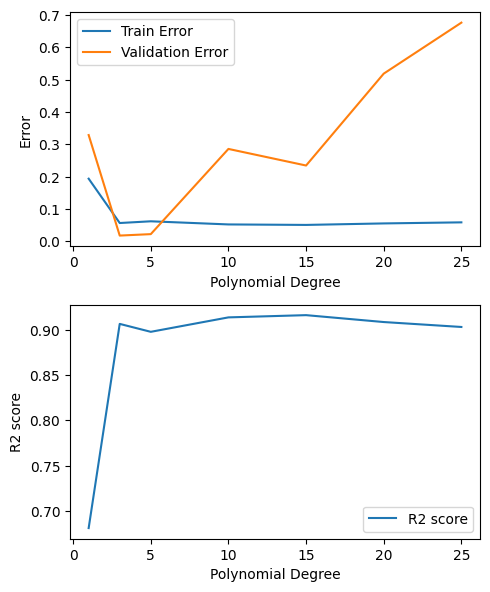

In [8]:
degrees = [1, 3, 5, 10, 15, 20, 25]

train_errors = []
val_errors = []
scores = []

for d in degrees:
    
    # Create polynomial features for normalized training data
    Xn = create_polynomial_features(xn, degree=d)

    # Normalize polynomial features
    X_mean = np.mean(Xn[:, 1:], axis=0)
    X_std = np.std(Xn[:, 1:], axis=0)
    Xn[:, 1:] = (Xn[:, 1:] - X_mean) / X_std

    # Training model
    # Normalized training polynomial features -> model -> Normalized training outputs
    model = Model(Xn, yn, x_mean, x_std, y_mean, y_std, X_mean, X_std)
    model.fit(eta=0.01, x_val=x_val, y_val=y_val)

    # Compute train error
    yhat_train = model.predict(x_train)
    train_error = np.mean((y_train - yhat_train)**2)

    # Compute validation error
    yhat_val = model.predict(x_val)
    val_error = np.mean((y_val - yhat_val)**2)

    train_errors.append(train_error)
    val_errors.append(val_error)
    scores.append(model.score())

plt.figure(figsize=(5, 6))

plt.subplot(211)
plt.plot(degrees, train_errors, label="Train Error")
plt.plot(degrees, val_errors, label="Validation Error")
plt.xlabel("Polynomial Degree")
plt.ylabel("Error")
plt.legend()

plt.subplot(212)
plt.plot(degrees, scores, label="R2 score")
plt.xlabel("Polynomial Degree")
plt.ylabel("R2 score")
plt.legend()

plt.tight_layout()
plt.show()